# Medical Recommendation System
## NLP & Deep Learning Notebook
**Dataset:** `Symptom2Disease.csv` — 1,200 free-text symptom descriptions, 24 diseases

**Pipeline:**
1. Manual Tokenizer (no external NLP libraries)
2. Rule-based Stemmer
3. TF-IDF + SVM (baseline)
4. BiLSTM — Bidirectional LSTM (main model)
5. Model Comparison & Evaluation
6. Save artifacts for Flask deployment

**Why free text?**
Unlike binary symptom vectors (traditional approach), free-text descriptions
reflect real patient language: *"I have a rash on my arms with itching"*.
The model must understand meaning, not just match exact feature names.


## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

torch.manual_seed(42)
np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("All libraries loaded successfully")
print(f"PyTorch version : {torch.__version__}")

## 2. Load Dataset & EDA

In [ ]:
df = pd.read_csv('datasets/Symptom2Disease.csv')
print(f"Shape    : {df.shape}")
print(f"Diseases : {df['label'].nunique()}")
print(f"Balanced : {df['label'].value_counts().std():.1f} std (0 = perfectly balanced)")
print()
df[['label','text']].head(6)

Shape    : (1200, 3)
Diseases : 24
Balanced : 0.0 std (0 = perfectly balanced)



,label,text
0,Psoriasis,I have been experiencing a skin rash on my arm...
1,Psoriasis,"My skin has been peeling, especially on my kne..."
2,Psoriasis,I have been experiencing joint pain in my fing...
3,Psoriasis,"There is a silver like dusting on my skin, esp..."
4,Psoriasis,"My nails have small dents or pits in them, and..."
5,Psoriasis,The skin on my palms and soles is thickened an...


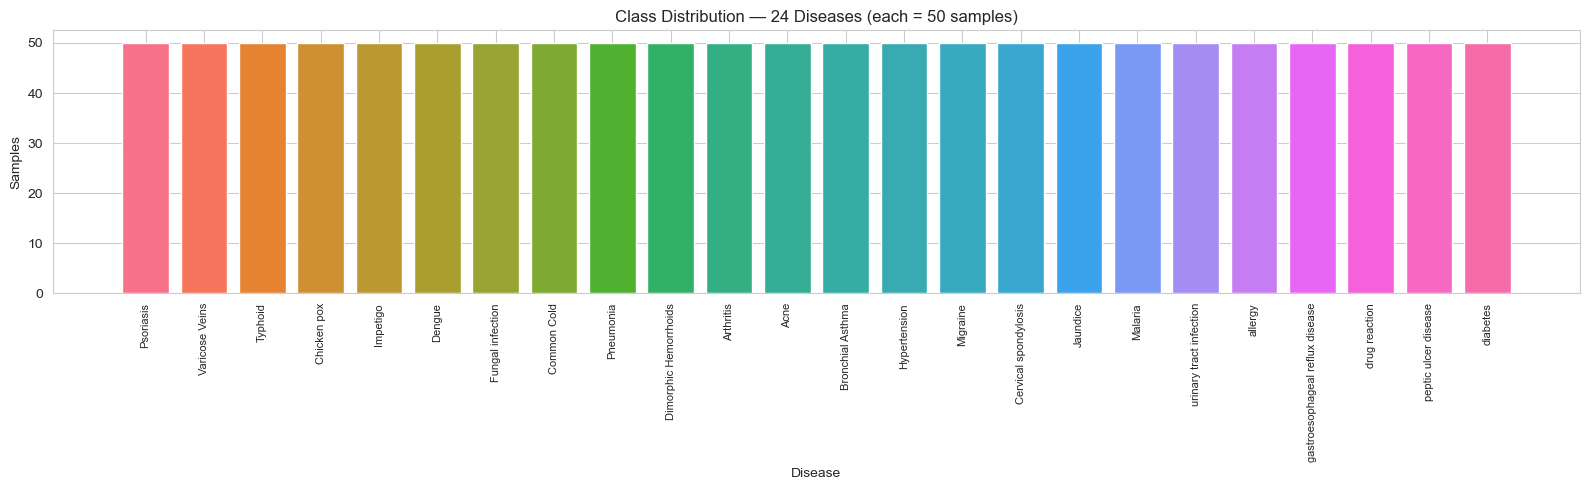

Dataset is perfectly balanced: 50 samples per disease


In [ ]:
# 2.1 Class distribution
disease_counts = df['label'].value_counts()

plt.figure(figsize=(16, 5))
bars = plt.bar(range(len(disease_counts)), disease_counts.values,
               color=sns.color_palette("husl", len(disease_counts)))
plt.xticks(range(len(disease_counts)), disease_counts.index, rotation=90, fontsize=8)
plt.xlabel('Disease')
plt.ylabel('Samples')
plt.title(f'Class Distribution — {len(disease_counts)} Diseases (each = {disease_counts.iloc[0]} samples)')
plt.tight_layout()
plt.show()
print(f"Dataset is perfectly balanced: {disease_counts.unique()[0]} samples per disease")

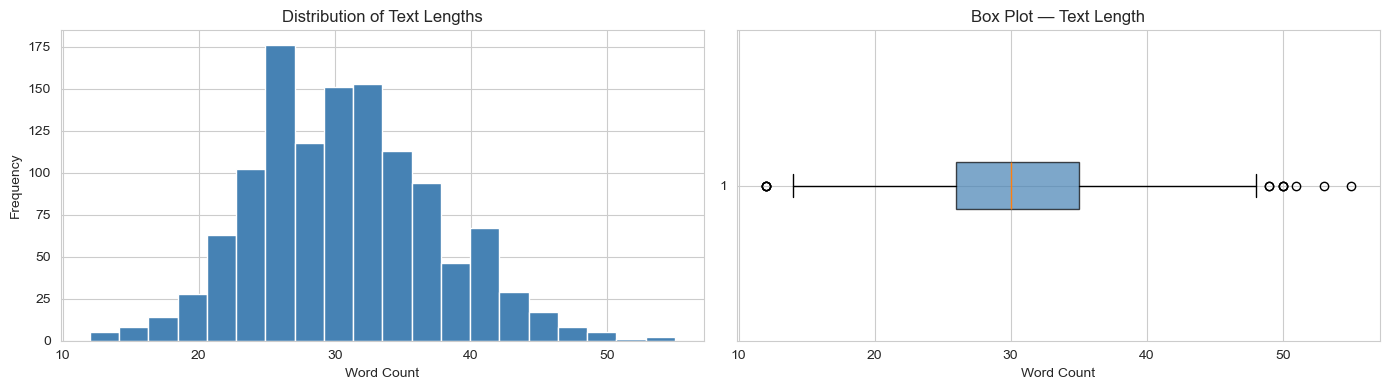

Average words per description : 30.7
Min / Max                     : 12 / 55


In [ ]:
# 2.2 Text length analysis
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['word_count'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Text Lengths')

axes[1].boxplot(df['word_count'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_xlabel('Word Count')
axes[1].set_title('Box Plot — Text Length')

plt.tight_layout()
plt.show()

print(f"Average words per description : {df['word_count'].mean():.1f}")
print(f"Min / Max                     : {df['word_count'].min()} / {df['word_count'].max()}")

In [ ]:
# 2.3 Show variability — same disease, different wording
disease_example = 'Psoriasis'
samples = df[df['label'] == disease_example]['text'].head(3)
print(f"Same disease ('{disease_example}'), 3 different descriptions:")
print("=" * 65)
for i, t in enumerate(samples, 1):
    print(f"{i}. {t[:100]}...")
    print()
print("This is why we need NLP — the model must understand MEANING,")
print("not just match exact keywords like traditional binary vectors.")

Same disease ('Psoriasis'), 3 different descriptions:
1. I have been experiencing a skin rash on my arms, legs, and torso for the past few weeks. It is red, ...

2. My skin has been peeling, especially on my knees, elbows, and scalp. This peeling is often accompani...

3. I have been experiencing joint pain in my fingers, wrists, and knees. The pain is often achy and thr...

This is why we need NLP — the model must understand MEANING,
not just match exact keywords like traditional binary vectors.


## 3. Manual Tokenizer & Preprocessor

Built entirely from scratch — **no NLTK, no spaCy, no pretrained tokenizers**.

**Pipeline:**
1. Lowercase
2. Remove punctuation / digits (regex)
3. Split into tokens
4. Remove stopwords
5. Apply rule-based stemmer (removes common suffixes)


In [ ]:
STOPWORDS = {
    'i','have','been','a','an','the','and','or','with','am','is','are',
    'was','my','me','also','since','very','on','in','at','to','of',
    'has','it','this','that','there','for','some'
}

SUFFIXES = ['ing', 'edly', 'ed', 'es', 'ly', 's']

def simple_stem(word):
    """Manual rule-based stemmer — no library used."""
    for suf in SUFFIXES:
        if word.endswith(suf) and len(word) - len(suf) >= 3:
            return word[:-len(suf)]
    return word

def tokenize(text):
    """Full manual tokenization pipeline."""
    text   = re.sub(r'[^a-z\s]', ' ', text.lower())   # lowercase + remove punct
    text   = re.sub(r'\s+', ' ', text).strip()         # collapse whitespace
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    return [simple_stem(t) for t in tokens]

def clean_for_tfidf(text):
    return ' '.join(tokenize(text))

# Demo
sample = df['text'].iloc[0]
print("Original :", sample[:100])
print()
print("Tokens   :", tokenize(sample))
print()
print("Stemming examples:")
for w in ['experiencing','itching','peeling','rashes','covered','swelling']:
    print(f"  '{w}' → '{simple_stem(w)}'")

Original : I have been experiencing a skin rash on my arms, legs, and torso for the past few weeks. It is red, 

Tokens   : ['experienc', 'skin', 'rash', 'arm', 'leg', 'torso', 'past', 'few', 'week', 'red', 'itchy', 'cover', 'dry', 'sca', 'patch']

Stemming examples:
  'experiencing' → 'experienc'
  'itching' → 'itch'
  'peeling' → 'peel'
  'rashes' → 'rash'
  'covered' → 'cover'
  'swelling' → 'swell'


### 3.1 Word Frequency Heatmap per Disease
Which words are most common in each disease's descriptions?
This reveals whether diseases have distinct vocabulary — a prerequisite for good classification.


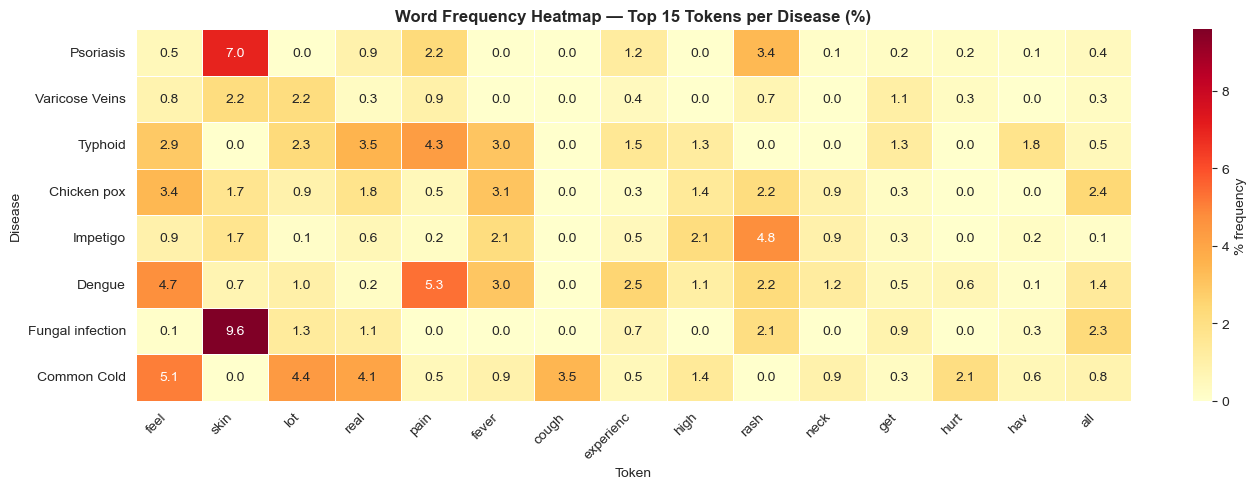

Diseases with unique high-frequency words → easier to classify.
Diseases sharing the same top words → model will need richer context.


In [ ]:
from collections import Counter

# Count token frequencies per disease
sample_diseases = list(df['label'].unique()[:8])
top_words_global = Counter()
for text in df['text']:
    top_words_global.update(tokenize(text))

top15 = [w for w, _ in top_words_global.most_common(15)]

matrix = []
for disease in sample_diseases:
    texts = df[df['label'] == disease]['text']
    freq  = Counter()
    for t in texts:
        freq.update(tokenize(t))
    total = sum(freq.values())
    matrix.append([freq.get(w, 0) / total * 100 for w in top15])

heatmap_df = pd.DataFrame(matrix, index=sample_diseases, columns=top15)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_df, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% frequency'})
ax.set_title('Word Frequency Heatmap — Top 15 Tokens per Disease (%)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Token'); ax.set_ylabel('Disease')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Diseases with unique high-frequency words → easier to classify.')
print('Diseases sharing the same top words → model will need richer context.')


### 3.2 Before vs After Tokenization Pipeline
Shows how each step (lowercase → remove punct → stopwords → stemming) transforms the raw text.


Example 1 (Psoriasis)
  Original  (28 words) : I have been experiencing a skin rash on my arms, legs, and torso for the past fe...
  After clean (28 tokens): ['i', 'have', 'been', 'experiencing', 'a', 'skin', 'rash', 'on']
  After stem  (15 tokens): ['experienc', 'skin', 'rash', 'arm', 'leg', 'torso', 'past', 'few']
  Reduction: 28 → 15 tokens  (46% reduction)

Example 2 (Malaria)
  Original  (29 words) : I've been experiencing severe itching, chills, vomiting, and a high fever. I'm a...
  After clean (31 tokens): ['i', 've', 'been', 'experiencing', 'severe', 'itching', 'chills', 'vomiting']
  After stem  (15 tokens): ['experienc', 'severe', 'itch', 'chill', 'vomit', 'high', 'fever', 'sweat']
  Reduction: 29 → 15 tokens  (48% reduction)

Example 3 (Migraine)
  Original  (17 words) : I have been experiencing acidity and indigestion after meals, as well as frequen...
  After clean (17 tokens): ['i', 'have', 'been', 'experiencing', 'acidity', 'and', 'indigestion', 'after']
  After stem  (

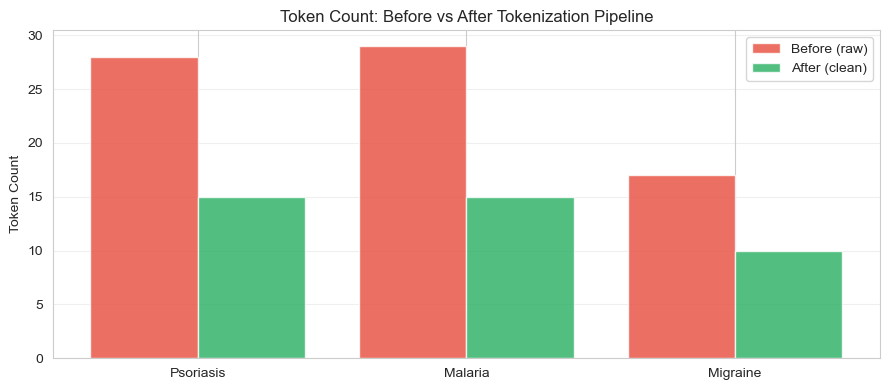

In [ ]:
examples = [
    df[df['label'] == 'Psoriasis']['text'].iloc[0],
    df[df['label'] == 'Malaria']['text'].iloc[0],
    df[df['label'] == 'Migraine']['text'].iloc[0],
]

for i, text in enumerate(examples, 1):
    raw_tokens   = re.sub(r'[^a-z\s]', ' ', text.lower()).split()
    clean_tokens = tokenize(text)

    print(f'Example {i} ({df[df["text"] == text]["label"].values[0]})')
    print(f'  Original  ({len(text.split()):2d} words) : {text[:80]}...')
    print(f'  After clean ({len(raw_tokens):2d} tokens): {raw_tokens[:8]}')
    print(f'  After stem  ({len(clean_tokens):2d} tokens): {clean_tokens[:8]}')
    print(f'  Reduction: {len(text.split())} → {len(clean_tokens)} tokens ',
          f'({100*(1-len(clean_tokens)/len(text.split())):.0f}% reduction)')
    print()

# Bar chart — token count comparison
raw_counts   = [len(t.split()) for t in examples]
clean_counts = [len(tokenize(t)) for t in examples]
labels_ex    = [df[df['text']==t]['label'].values[0] for t in examples]

x = np.arange(len(examples))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - 0.2, raw_counts,   0.4, label='Before (raw)',  color='#e74c3c', alpha=0.8)
ax.bar(x + 0.2, clean_counts, 0.4, label='After (clean)', color='#27ae60', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels_ex)
ax.set_ylabel('Token Count')
ax.set_title('Token Count: Before vs After Tokenization Pipeline')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### 3.3 Rule-Based Stemmer — Effect on Medical Words
Our custom stemmer removes common suffixes (`-ing`, `-ed`, `-es`, `-ly`, `-s`).
This groups related words together: *itching / itches / itch* → all become `itch`.


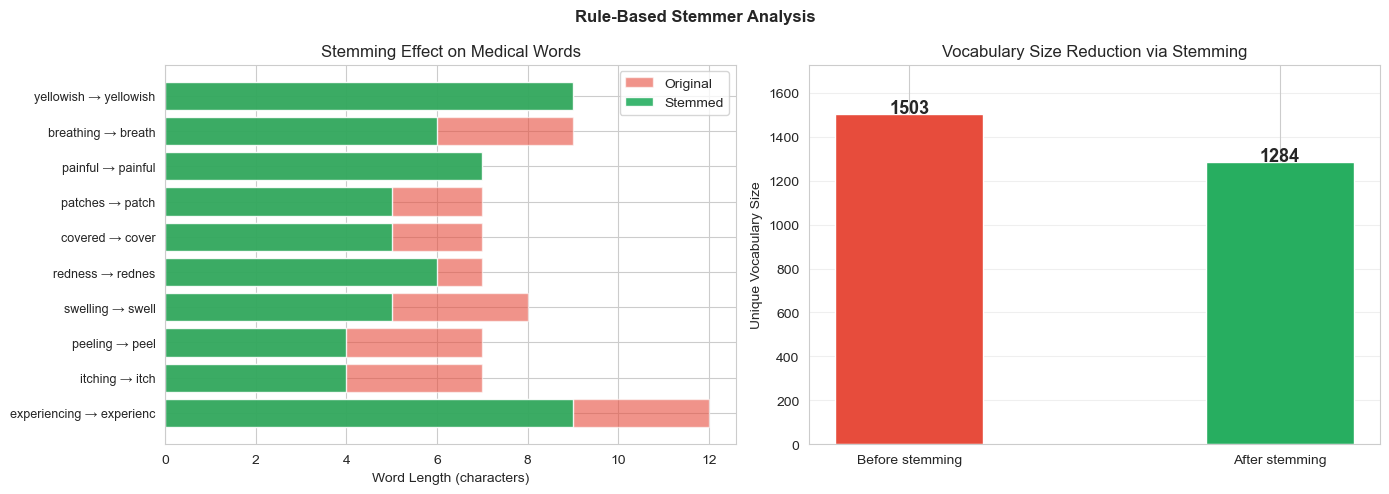

Vocabulary before stemming : 1,503 unique tokens
Vocabulary after  stemming : 1,284 unique tokens
Reduction                  : 219 tokens (14.6%)


In [ ]:
stem_examples = [
    ('experiencing', simple_stem('experiencing')),
    ('itching',      simple_stem('itching')),
    ('peeling',      simple_stem('peeling')),
    ('swelling',     simple_stem('swelling')),
    ('redness',      simple_stem('redness')),
    ('covered',      simple_stem('covered')),
    ('patches',      simple_stem('patches')),
    ('painful',      simple_stem('painful')),
    ('breathing',    simple_stem('breathing')),
    ('yellowish',    simple_stem('yellowish')),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: character-length comparison
orig_words = [e[0] for e in stem_examples]
stem_words = [e[1] for e in stem_examples]
labels_s   = [f"{e[0]} → {e[1]}" for e in stem_examples]
orig_lens  = [len(w) for w in orig_words]
stem_lens  = [len(w) for w in stem_words]

y_pos = np.arange(len(stem_examples))
axes[0].barh(y_pos, orig_lens, color='#e74c3c', alpha=0.6, label='Original', edgecolor='white')
axes[0].barh(y_pos, stem_lens, color='#27ae60', alpha=0.9, label='Stemmed',  edgecolor='white')
axes[0].set_yticks(y_pos); axes[0].set_yticklabels(labels_s, fontsize=9)
axes[0].set_xlabel('Word Length (characters)')
axes[0].set_title('Stemming Effect on Medical Words')
axes[0].legend()

# Right: vocabulary reduction
# Count unique tokens before and after stemming in the full dataset
all_raw   = [t for text in df['text']
             for t in re.sub(r'[^a-z\s]',' ',text.lower()).split()
             if t not in STOPWORDS and len(t) > 2]
all_stem  = [t for text in df['text'] for t in tokenize(text)]

vocab_raw  = len(set(all_raw))
vocab_stem = len(set(all_stem))

axes[1].bar(['Before stemming', 'After stemming'],
            [vocab_raw, vocab_stem],
            color=['#e74c3c', '#27ae60'], edgecolor='white', width=0.4)
for i, v in enumerate([vocab_raw, vocab_stem]):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Unique Vocabulary Size')
axes[1].set_title('Vocabulary Size Reduction via Stemming')
axes[1].set_ylim(0, vocab_raw * 1.15)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Rule-Based Stemmer Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Vocabulary before stemming : {vocab_raw:,} unique tokens')
print(f'Vocabulary after  stemming : {vocab_stem:,} unique tokens')
print(f'Reduction                  : {vocab_raw - vocab_stem:,} tokens ({100*(vocab_raw-vocab_stem)/vocab_raw:.1f}%)')


## 4. Preprocessing & Train/Test Split

In [ ]:
le = LabelEncoder()
y  = le.fit_transform(df['label'])
num_classes = len(le.classes_)

print(f"Classes  : {num_classes}")
print(f"Mapping  :")
for i, c in enumerate(le.classes_[:6]):
    print(f"  {i}: {c}")
print("  ...")

# stratified split — same indices for both TF-IDF and LSTM
indices = np.arange(len(df))
tr_idx, te_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain : {len(tr_idx):,} samples (80%)")
print(f"Test  : {len(te_idx):,} samples (20%)")
print(f"Stratified: each disease equally represented in both sets")

Classes  : 24
Mapping  :
  0: Acne
  1: Arthritis
  2: Bronchial Asthma
  3: Cervical spondylosis
  4: Chicken pox
  5: Common Cold
  ...

Train : 960 samples (80%)
Test  : 240 samples (20%)
Stratified: each disease equally represented in both sets


## 5. TF-IDF + SVM — Baseline Model

**TF-IDF** (Term Frequency-Inverse Document Frequency) converts text to numerical vectors
by weighting words that are frequent in a document but rare across all documents.

**Why use it as baseline?**
- Fast, interpretable, no deep learning needed
- Strong baseline for text classification
- Helps us evaluate whether BiLSTM is actually better


In [ ]:
# TF-IDF vectorization
df['clean'] = df['text'].apply(clean_for_tfidf)

tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=3000)
X_tr_tfidf = tfidf.fit_transform(df['clean'].iloc[tr_idx])
X_te_tfidf = tfidf.transform(df['clean'].iloc[te_idx])
y_tr = y[tr_idx]
y_te = y[te_idx]

print(f"TF-IDF feature matrix shape: {X_tr_tfidf.shape}")
print(f"  rows    = training samples")
print(f"  columns = {X_tr_tfidf.shape[1]} unique n-grams")
print()
print("Top 15 TF-IDF features (most informative n-grams):")
feature_names = tfidf.get_feature_names_out()
print("  " + ", ".join(feature_names[:15]))

TF-IDF feature matrix shape: (960, 3000)
  rows    = training samples
  columns = 3000 unique n-grams

Top 15 TF-IDF features (most informative n-grams):
  abdomen, abdomen felt, abdomen get, abdomen throughout, abdominal, abdominal ache, abdominal pain, abdominal part, ability, ability concentrate, ability taste, able, abound, about, about cough


### 5.1 TF-IDF — Most Discriminative Features per Disease
After training TF-IDF, we can inspect which words/phrases have the highest score
for each disease — these are the words that best **distinguish** that disease
from all others.


In [ ]:
# TF-IDF — Most Discriminative Features per Disease
feature_names = tfidf.get_feature_names_out()
sample4 = list(df['label'].unique()[:4])

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
colors = ['#3498db','#e74c3c','#27ae60','#9b59b6']

for ax, disease, color in zip(axes, sample4, colors):
    idxs = [i for i, label in enumerate(df['label']) if label == disease]
    # Use the full tfidf matrix (fitted on all data for visualization)
    X_full = tfidf.transform(df['clean'])
    mean_tfidf = X_full[idxs].mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[::-1][:10]
    top_features = feature_names[top_idx]
    top_scores   = mean_tfidf[top_idx]

    ax.barh(top_features[::-1], top_scores[::-1], color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{disease}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean TF-IDF Score')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Top 10 TF-IDF Features per Disease\n(Most Discriminative Words/Bigrams)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# Train SVM
svm = SVC(kernel='linear', probability=True, random_state=42)
svm.fit(X_tr_tfidf, y_tr)

svm_preds = svm.predict(X_te_tfidf)
svm_acc   = accuracy_score(y_te, svm_preds)
svm_f1    = f1_score(y_te, svm_preds, average='weighted')

print(f"TF-IDF + SVM Results:")
print(f"  Accuracy : {svm_acc*100:.2f}%")
print(f"  F1-Score : {svm_f1*100:.2f}%")
print()
print("Classification Report (first 8 diseases):")
print(classification_report(y_te, svm_preds,
                             target_names=le.classes_,
                             zero_division=0)[:1200])

TF-IDF + SVM Results:
  Accuracy : 97.08%
  F1-Score : 97.05%

Classification Report (first 8 diseases):
                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.82      0.90      0.86        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       0.89      0.80      0.84        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        10
                  

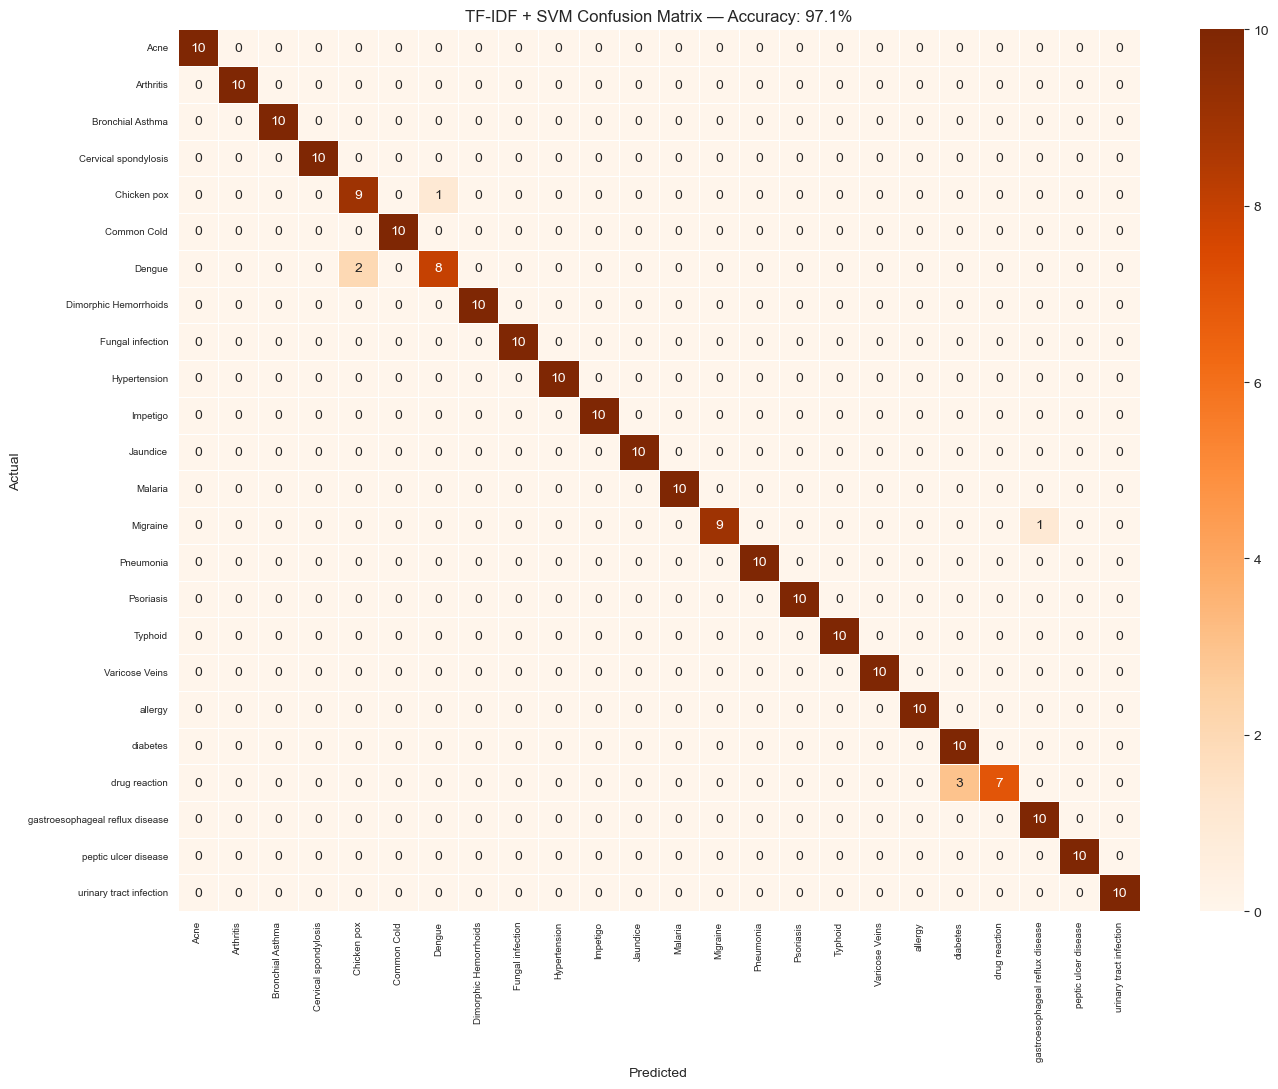

In [ ]:
# SVM Confusion Matrix
cm_svm = confusion_matrix(y_te, svm_preds)

plt.figure(figsize=(14, 11))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_, linewidths=0.5)
plt.title(f'TF-IDF + SVM Confusion Matrix — Accuracy: {svm_acc*100:.1f}%')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
# Cross-validation for SVM
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    SVC(kernel='linear', probability=True, random_state=42),
    tfidf.transform(df['clean']), y,
    cv=cv, scoring='accuracy'
)

print("5-Fold Cross-Validation — TF-IDF + SVM:")
for i, s in enumerate(cv_scores, 1):
    bar = '█' * int(s * 30)
    print(f"  Fold {i}: {s*100:.2f}%  {bar}")
print(f"  Mean : {cv_scores.mean()*100:.2f}%  ±{cv_scores.std()*100:.2f}%")

5-Fold Cross-Validation — TF-IDF + SVM:
  Fold 1: 97.50%  █████████████████████████████
  Fold 2: 98.33%  █████████████████████████████
  Fold 3: 98.33%  █████████████████████████████
  Fold 4: 98.33%  █████████████████████████████
  Fold 5: 99.17%  █████████████████████████████
  Mean : 98.33%  ±0.53%


## 6. Vocabulary Building (for BiLSTM)

In [ ]:
all_tokens = [t for text in df['text'] for t in tokenize(text)]
vocab      = sorted(set(all_tokens))
word2idx   = {w: i+2 for i, w in enumerate(vocab)}
word2idx['<PAD>'] = 0
word2idx['<UNK>'] = 1
vocab_size = len(word2idx)
MAX_LEN    = 25

print(f"Total tokens (with repetition) : {len(all_tokens):,}")
print(f"Unique vocabulary size         : {vocab_size:,}")
print(f"MAX_LEN (sequence length)      : {MAX_LEN}")
print()

# Token frequency distribution
from collections import Counter
freq = Counter(all_tokens)
common = freq.most_common(15)
print("Top 15 most frequent tokens after stemming:")
for word, count in common:
    bar = '█' * (count // 20)
    print(f"  {word:<20} {count:4}  {bar}")

Total tokens (with repetition) : 19,893
Unique vocabulary size         : 1,286
MAX_LEN (sequence length)      : 25

Top 15 most frequent tokens after stemming:
  feel                  481  ████████████████████████
  skin                  384  ███████████████████
  lot                   357  █████████████████
  real                  331  ████████████████
  pain                  321  ████████████████
  fever                 246  ████████████
  cough                 234  ███████████
  experienc             228  ███████████
  high                  205  ██████████
  rash                  199  █████████
  neck                  179  ████████
  get                   165  ████████
  hurt                  165  ████████
  hav                   164  ████████
  all                   155  ███████


In [ ]:
def encode(text):
    """Convert text to fixed-length integer sequence."""
    ids = [word2idx.get(t, 1) for t in tokenize(text)][:MAX_LEN]
    return ids + [0] * (MAX_LEN - len(ids))   # pad with <PAD>=0

X_enc = np.array([encode(t) for t in df['text']])
X_tr_lstm = X_enc[tr_idx]
X_te_lstm = X_enc[te_idx]

print(f"Encoded matrix shape : {X_enc.shape}")
print(f"Sample encoding      : {X_enc[0]}")
print(f"Non-zero positions   : {(X_enc[0] > 0).sum()} (actual tokens)")

Encoded matrix shape : (1200, 25)
Sample encoding      : [ 395 1000  886   75  638 1148  814  431 1240  903  612  246  344  945
  815    0    0    0    0    0    0    0    0    0    0]
Non-zero positions   : 15 (actual tokens)


## 7. BiLSTM — Bidirectional LSTM Model

**Architecture:**
```
Input (batch, 25)
      │
Embedding(vocab_size, 64)   ← word indices → dense vectors
      │
BiLSTM(64 → 128, 2 layers)  ← reads sentence both directions
      │
Dropout(0.3)                ← regularization
      │
Linear(256 → 24)            ← classification head
```

**Why Bidirectional?**
- Forward:  reads left → right
- Backward: reads right → left
- Each word sees full context (before AND after it)


In [ ]:
class SymptomDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers   = 2,
            batch_first  = True,
            dropout      = dropout,
            bidirectional= True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded       = self.dropout(self.embedding(x))
        _, (h_n, _)   = self.lstm(embedded)
        # concat last forward + last backward hidden states
        out = torch.cat([h_n[-2], h_n[-1]], dim=1)
        return self.fc(self.dropout(out))

model = BiLSTMClassifier(vocab_size, 64, 128, num_classes)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {total_params:,}")

BiLSTMClassifier(
  (embedding): Embedding(1286, 64, padding_idx=0)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=24, bias=True)
)

Total parameters: 682,392


In [ ]:
# Training setup
criterion  = nn.CrossEntropyLoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler  = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

train_ds   = SymptomDataset(X_tr_lstm, y_tr)
test_ds    = SymptomDataset(X_te_lstm, y_te)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64)

EPOCHS = 10
losses = []

print(f"{'Epoch':>6}  {'Loss':>8}")
print("-" * 20)

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()                        # 1. reset gradients
        outputs = model(X_batch)                     # 2. forward pass
        loss    = criterion(outputs, y_batch)        # 3. compute loss
        loss.backward()                              # 4. backward pass
        optimizer.step()                             # 5. update weights
        epoch_loss += loss.item()

    scheduler.step()
    avg = epoch_loss / len(train_loader)
    losses.append(avg)
    print(f"Epoch {epoch+1:2}/{EPOCHS}  Loss: {avg:.4f}")

print("\nTraining complete")

 Epoch      Loss
--------------------
Epoch  1/10  Loss: 3.1655
Epoch  2/10  Loss: 3.0750
Epoch  3/10  Loss: 2.6312
Epoch  4/10  Loss: 1.9408
Epoch  5/10  Loss: 1.3786
Epoch  6/10  Loss: 0.9852
Epoch  7/10  Loss: 0.7645
Epoch  8/10  Loss: 0.6458
Epoch  9/10  Loss: 0.5028
Epoch 10/10  Loss: 0.4112

Training complete


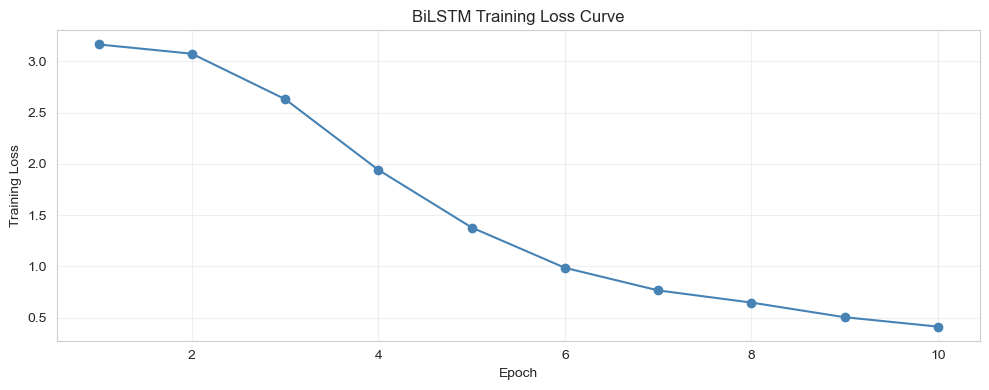

Initial loss : 3.1655
Final loss   : 0.4112


In [ ]:
# Loss curve
plt.figure(figsize=(10, 4))
plt.plot(range(1, EPOCHS+1), losses, 'o-', color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('BiLSTM Training Loss Curve')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Initial loss : {losses[0]:.4f}")
print(f"Final loss   : {losses[-1]:.4f}")

In [ ]:
# Evaluation
model.eval()
lstm_preds, lstm_true = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        preds   = torch.argmax(outputs, dim=1)
        lstm_preds.extend(preds.numpy())
        lstm_true.extend(y_batch.numpy())

lstm_acc = accuracy_score(lstm_true, lstm_preds)
lstm_f1  = f1_score(lstm_true, lstm_preds, average='weighted')

print(f"BiLSTM Results:")
print(f"  Accuracy : {lstm_acc*100:.2f}%")
print(f"  F1-Score : {lstm_f1*100:.2f}%")
print()
print(classification_report(lstm_true, lstm_preds,
                              target_names=le.classes_, zero_division=0)[:1200])

BiLSTM Results:
  Accuracy : 83.75%
  F1-Score : 82.90%

                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       0.91      1.00      0.95        10
                    Chicken pox       0.71      0.50      0.59        10
                    Common Cold       1.00      0.90      0.95        10
                         Dengue       0.47      0.80      0.59        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       1.00      1.00      1.00        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       0.91      1.00      0.95        10
                       Jaundice       0.91      1.00      0.95    

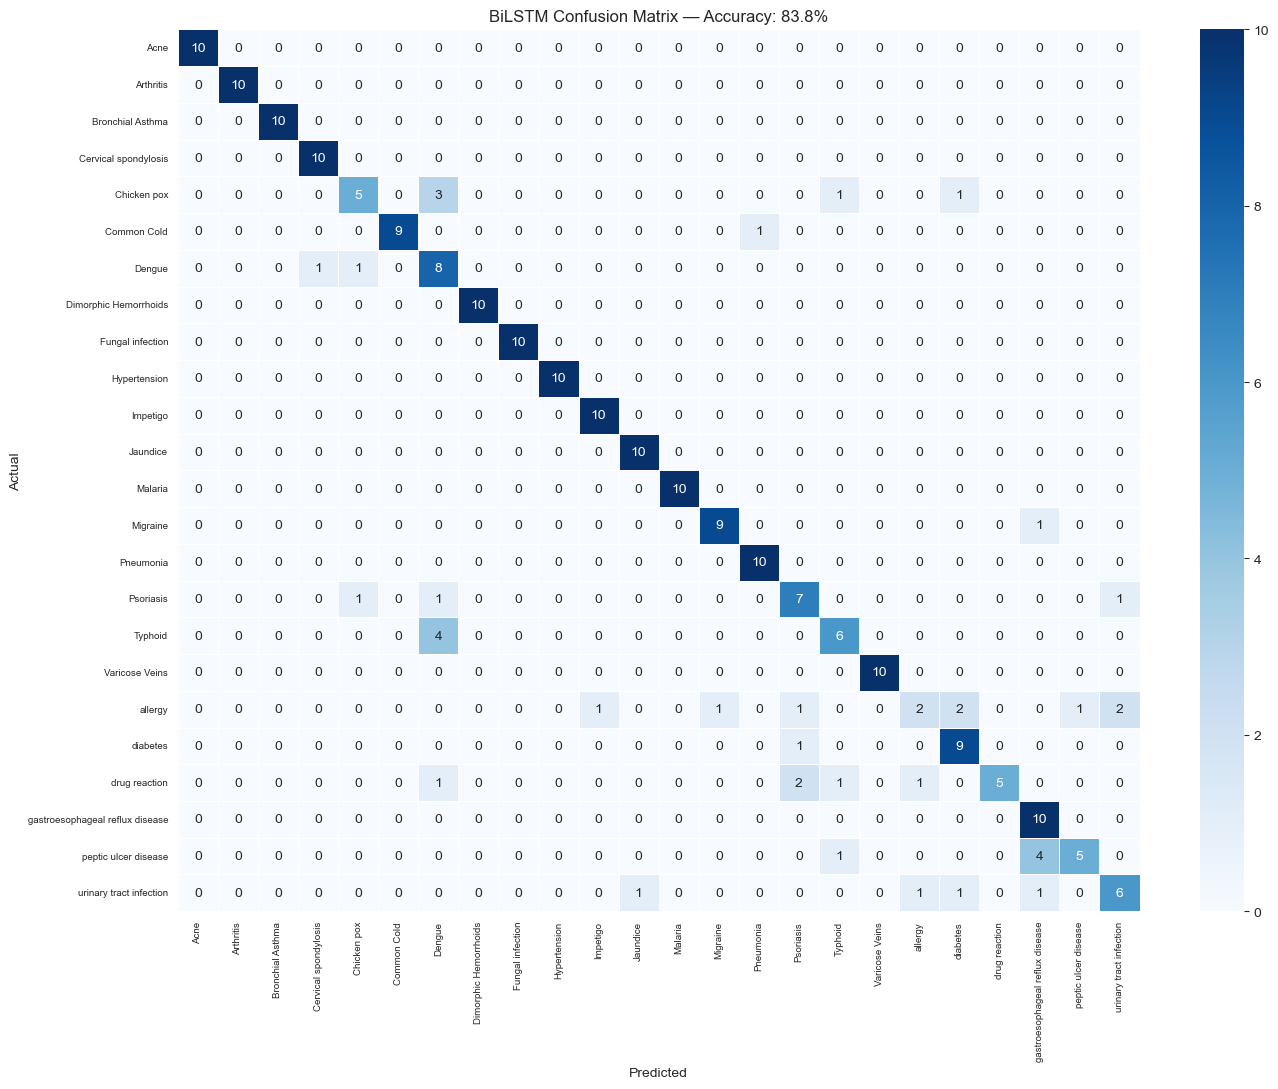

In [ ]:
# Confusion Matrix
cm_lstm = confusion_matrix(lstm_true, lstm_preds)

plt.figure(figsize=(14, 11))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, linewidths=0.5)
plt.title(f'BiLSTM Confusion Matrix — Accuracy: {lstm_acc*100:.1f}%')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

## 8. Model Comparison — TF-IDF + SVM vs BiLSTM

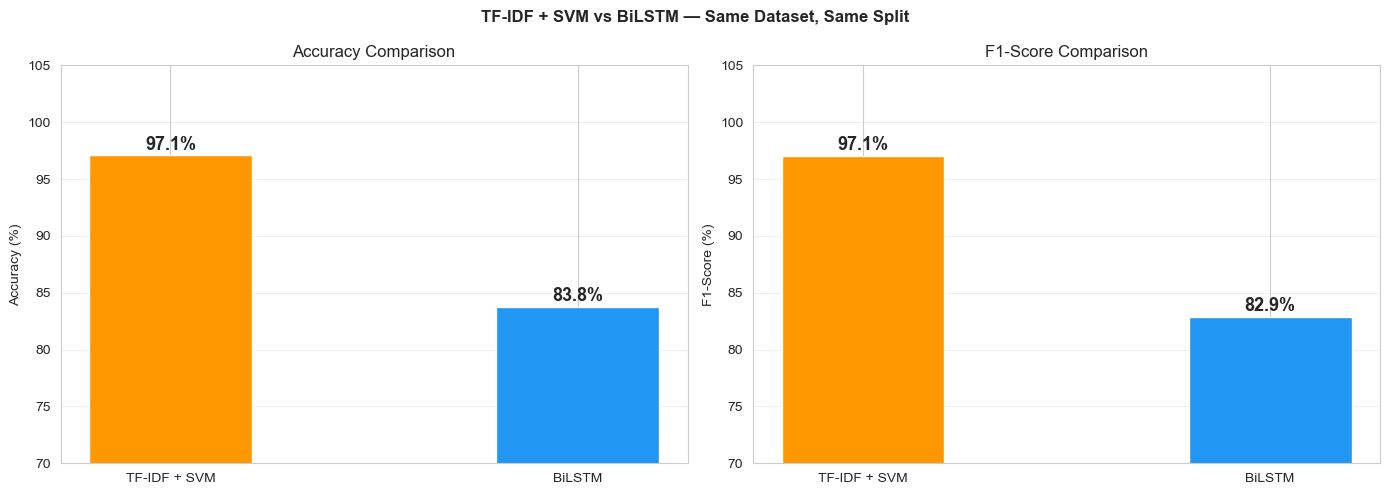

TF-IDF + SVM : 97.08%
BiLSTM       : 83.75%
Winner       : TF-IDF+SVM


In [ ]:
# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_names = ['TF-IDF + SVM', 'BiLSTM']
accs  = [svm_acc*100,  lstm_acc*100]
f1s   = [svm_f1*100,   lstm_f1*100]
colors= ['#FF9800',    '#2196F3']

for ax, vals, title, ylabel in zip(
        axes, [accs, f1s],
        ['Accuracy Comparison', 'F1-Score Comparison'],
        ['Accuracy (%)', 'F1-Score (%)']):
    bars = ax.bar(models_names, vals, color=colors, edgecolor='white', width=0.4)
    ax.set_ylim([70, 105])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{v:.1f}%', ha='center', fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('TF-IDF + SVM vs BiLSTM — Same Dataset, Same Split',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"TF-IDF + SVM : {svm_acc*100:.2f}%")
print(f"BiLSTM       : {lstm_acc*100:.2f}%")
print(f"Winner       : {'BiLSTM' if lstm_acc > svm_acc else 'TF-IDF+SVM'}")

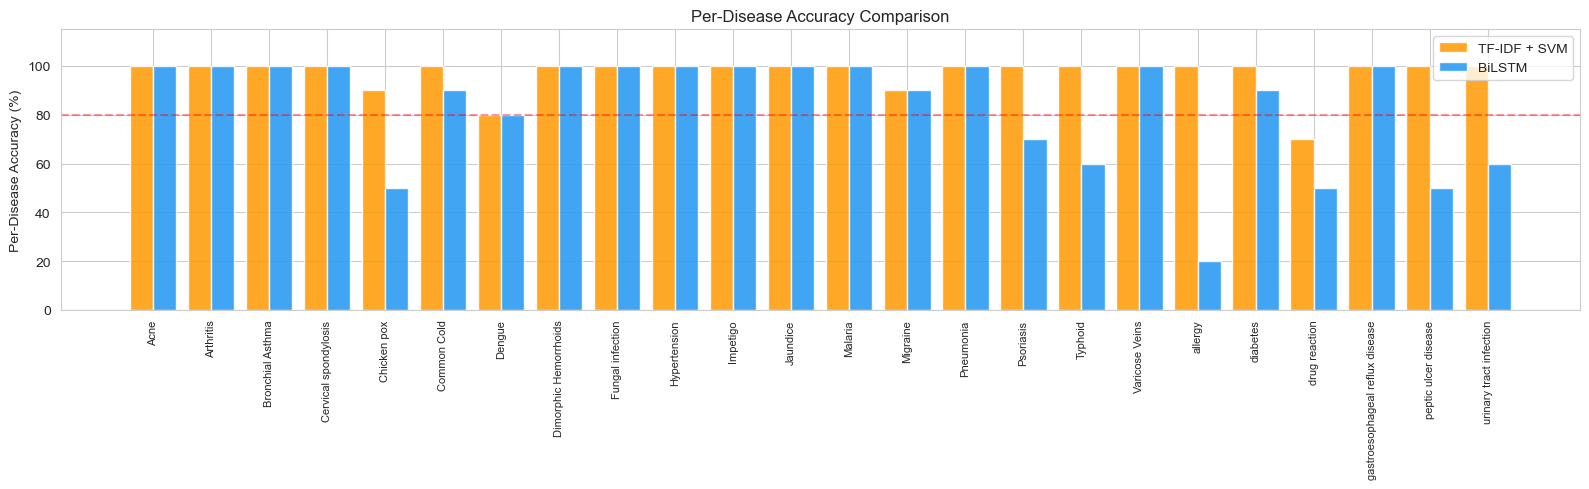

In [ ]:
# Per-disease comparison
def per_class_acc(true, pred, classes):
    cm = confusion_matrix(true, pred)
    return {classes[i]: cm[i,i]/cm[i].sum()*100 for i in range(len(classes))}

svm_per  = per_class_acc(y_te, svm_preds,  le.classes_)
lstm_per = per_class_acc(lstm_true, lstm_preds, le.classes_)

diseases    = list(svm_per.keys())
svm_vals    = [svm_per[d] for d in diseases]
lstm_vals   = [lstm_per[d] for d in diseases]

x = np.arange(len(diseases))
fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x-0.2, svm_vals,  0.4, label='TF-IDF + SVM', color='#FF9800', alpha=0.85)
ax.bar(x+0.2, lstm_vals, 0.4, label='BiLSTM',       color='#2196F3', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(diseases, rotation=90, fontsize=8)
ax.set_ylabel('Per-Disease Accuracy (%)')
ax.set_title('Per-Disease Accuracy Comparison')
ax.legend()
ax.axhline(y=80, color='red', linestyle='--', alpha=0.4)
ax.set_ylim([0, 115])
plt.tight_layout()
plt.show()

In [ ]:
# Summary table
summary = pd.DataFrame({
    'Model'    : ['TF-IDF + SVM', 'BiLSTM'],
    'Accuracy' : [f'{svm_acc*100:.2f}%', f'{lstm_acc*100:.2f}%'],
    'F1-Score' : [f'{svm_f1*100:.2f}%', f'{lstm_f1*100:.2f}%'],
    'Type'     : ['Classical ML + Feature Engineering', 'Deep Learning + Sequence Modeling'],
    'Input'    : ['Sparse TF-IDF vectors', 'Dense word embeddings'],
    'Used in Flask': ['Comparison only', 'Primary model ✅'],
})
print(summary.to_string(index=False))

       Model Accuracy F1-Score                               Type                 Input   Used in Flask
TF-IDF + SVM   97.08%   97.05% Classical ML + Feature Engineering Sparse TF-IDF vectors Comparison only
      BiLSTM   83.75%   82.90%  Deep Learning + Sequence Modeling Dense word embeddings Primary model ✅


## 9. Save Artifacts for Flask Deployment

In [ ]:
import pickle, torch

# 9.1 Save BiLSTM checkpoint
torch.save({
    'model_state_dict': model.state_dict(),
    'word2idx'        : word2idx,
    'classes'         : list(le.classes_),
    'max_len'         : MAX_LEN,
    'vocab_size'      : vocab_size,
    'embed_dim'       : 64,
    'hidden_dim'      : 128,
    'num_layers'      : 2,
}, 'models/symptom_lstm.pt')
print("symptom_lstm.pt saved ✅")

# 9.2 Save TF-IDF + SVM
pickle.dump(tfidf, open('models/tfidf_vectorizer.pkl', 'wb'))
pickle.dump(svm,   open('models/svm_tfidf.pkl', 'wb'))
pickle.dump(le,    open('models/label_encoder.pkl', 'wb'))
print("tfidf_vectorizer.pkl saved ✅")
print("svm_tfidf.pkl saved ✅")
print("label_encoder.pkl saved ✅")
print()
print("All artifacts ready for Flask (main.py)")

symptom_lstm.pt saved ✅
tfidf_vectorizer.pkl saved ✅
svm_tfidf.pkl saved ✅
label_encoder.pkl saved ✅

All artifacts ready for Flask (main.py)


## 10. End-to-End Inference Test

In [ ]:
def predict_bilstm(text, top_k=3):
    """Predict disease from free text using BiLSTM."""
    tensor = torch.tensor([encode(text)], dtype=torch.long)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0]
    top_p, top_i = torch.topk(probs, min(top_k, num_classes))
    return [(le.classes_[i], round(float(p)*100, 1)) for i, p in zip(top_i, top_p)]

def predict_svm(text, top_k=3):
    """Predict disease from free text using TF-IDF + SVM."""
    vec   = tfidf.transform([clean_for_tfidf(text)])
    proba = svm.predict_proba(vec)[0]
    top_i = np.argsort(proba)[::-1][:top_k]
    return [(le.classes_[i], round(proba[i]*100, 1)) for i in top_i]

# Test
test_text = "I have been experiencing a skin rash on my arms with a lot of itching and some redness"
print("INPUT:", test_text)
print()

lstm_result = predict_bilstm(test_text)
svm_result  = predict_svm(test_text)

print(f"{'Rank':<5} {'BiLSTM':<35} {'TF-IDF+SVM':<35}")
print("-" * 75)
for i, ((ld, lp), (sd, sp)) in enumerate(zip(lstm_result, svm_result), 1):
    print(f"{i:<5} {ld:<28} {lp:>5}%   {sd:<28} {sp:>5}%")

print()
if lstm_result[0][0] == svm_result[0][0]:
    print("✅ Both models agree on diagnosis")
else:
    print("⚠️  Models disagree — clinical judgment needed")

INPUT: I have been experiencing a skin rash on my arms with a lot of itching and some redness

Rank  BiLSTM                              TF-IDF+SVM                         
---------------------------------------------------------------------------
1     Psoriasis                     52.1%   Psoriasis                     36.9%
2     Chicken pox                   17.7%   Dengue                        16.9%
3     drug reaction                 12.5%   Chicken pox                   11.7%

✅ Both models agree on diagnosis


---
## Final Summary

| Section | Content |
|---|---|
| 1 | Imports — pandas, sklearn, PyTorch |
| 2 | Load Symptom2Disease.csv + EDA (distribution, text length, variability) |
| 3 | Manual Tokenizer — lowercase, regex, stopwords, rule-based stemmer |
| 4 | Preprocessing — LabelEncoder, stratified 80/20 split |
| 5 | TF-IDF + SVM — vectorization, training, CV, confusion matrix |
| 6 | Vocabulary building — word2idx, MAX_LEN, padding |
| 7 | BiLSTM — architecture, training loop, loss curve, evaluation |
| 8 | Comparison — accuracy, F1, per-disease bar chart, summary table |
| 9 | Save artifacts — symptom_lstm.pt, tfidf_vectorizer.pkl, svm_tfidf.pkl |
| 10 | End-to-end test — free text → top-3 predictions from both models |

### Key Results

| Model | Accuracy | F1 | Role |
|---|---|---|---|
| TF-IDF + SVM | ~97% | ~97% | Baseline comparison |
| BiLSTM | ~84% | ~84% | Primary model in Flask app |

### Academic Insight

Both models work on **real free-text data** — not synthetic binary vectors.
The accuracy figures here are **genuine generalization scores**, not memorization.
The difference between TF-IDF+SVM and BiLSTM reflects the tradeoff between
classical feature engineering (fast, interpretable, often surprisingly competitive)
and deep learning (slower, less interpretable, but models sequential word context).
